In [ ]:
import pandas as pd
import numpy as np
import itertools
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics
import matplotlib.pyplot as plt

| Library          | Use                  |
| ---------------- | -------------------- |
| pandas           | Data handling        |
| numpy            | Numerical operations |
| CountVectorizer  | Text → Numbers       |
| train_test_split | Split data           |
| MultinomialNB    | Classification model |
| metrics          | Accuracy calculation |
| matplotlib       | Visualization        |


Load Dataset

In [ ]:
df=pd.read_csv('news.csv', index_col=None, on_bad_lines='skip')

View Dataset

In [ ]:
df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


Remove Unwanted Column

Removes unnecessary index column.

Before:

Unnamed:0
title
text
label

After:

title
text
label

In [ ]:
dataset=df.drop("Unnamed: 0",axis=1)

View Clean Dataset

Displays cleaned dataset.

In [ ]:
dataset

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...
6330,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


Create Target Variable

Stores labels.

Output:

FAKE
REAL
FAKE
REAL
...

In [ ]:
y=dataset["label"]

Split Data

| Dataset  | Percentage |
| -------- | ---------- |
| Training | 67%        |
| Testing  | 33%        |


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(dataset['text'], y, test_size=0.33, random_state=53)

Convert Text into Numbers

Machine Learning cannot understand text.



In [ ]:
count_vectorizer = CountVectorizer(stop_words='english')
count_train = count_vectorizer.fit_transform(X_train)
print(count_train)
count_test = count_vectorizer.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1119820 stored elements and shape (4244, 56922)>
  Coords	Values
  (1, 42470)	1
  (1, 12105)	1
  (1, 54177)	1
  (1, 50628)	1
  (1, 15924)	2
  (1, 44520)	2
  (1, 51896)	2
  (1, 35783)	4
  (1, 35256)	1
  (1, 21881)	1
  (1, 42534)	1
  (1, 8399)	1
  (1, 29531)	2
  (1, 15927)	2
  (1, 25686)	1
  (1, 49203)	2
  (1, 16814)	1
  (1, 36087)	1
  (1, 21568)	1
  (1, 25684)	1
  (1, 38823)	1
  (1, 47506)	1
  (1, 36831)	1
  (2, 16972)	1
  (2, 762)	1
  :	:
  (4243, 41435)	1
  (4243, 53607)	1
  (4243, 659)	1
  (4243, 38834)	1
  (4243, 19003)	1
  (4243, 11415)	1
  (4243, 7545)	1
  (4243, 22426)	1
  (4243, 54007)	1
  (4243, 7113)	1
  (4243, 4932)	1
  (4243, 39497)	1
  (4243, 50053)	1
  (4243, 38849)	1
  (4243, 20702)	1
  (4243, 42139)	1
  (4243, 17247)	1
  (4243, 50052)	1
  (4243, 55228)	1
  (4243, 29255)	1
  (4243, 49435)	1
  (4243, 11257)	1
  (4243, 52945)	1
  (4243, 20905)	1
  (4243, 7962)	1


Check Vocabulary Size

In [ ]:
dir(count_train)

['T',
 '__abs__',
 '__abstractmethods__',
 '__add__',
 '__array_priority__',
 '__bool__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__div__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__idiv__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__pow__',
 '__radd__',
 '__rdiv__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmatmul__',
 '__rmul__',
 '__round__',
 '__rsub__',
 '__rtruediv__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__weakref__',
 '_abc_impl',
 '_add_dense',
 '_add_sparse',
 '_allow_nd',
 '_argminmax',
 '_argminmax_axis',
 '_ascontainer',
 '_asfptype',
 '_asindices',
 '_binopt',
 '_

Counts unique words.

In [ ]:
len(count_vectorizer.get_feature_names_out())

56922

View Numerical Matrix

Displays text converted to numbers.

In [ ]:
print(count_train.toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Train Naive Bayes Model

Train model using news articles.

Model learns:

Word patterns
FAKE patterns
REAL patterns

Make Predictions

Predicts labels for unseen news.

Example:

['FAKE','REAL','REAL']

In [ ]:
clf = MultinomialNB()

clf.fit(count_train, y_train)
pred = clf.predict(count_test)
score = metrics.accuracy_score(y_test, pred)
print("accuracy:   %0.3f" % score)

cm = metrics.confusion_matrix(y_test, pred, labels=['FAKE', 'REAL'])

accuracy:   0.893


Classification Report

In [ ]:
from sklearn.metrics import classification_report

report=classification_report(y_test, pred)

In [ ]:
print(report)

              precision    recall  f1-score   support

        FAKE       0.92      0.86      0.89      1008
        REAL       0.88      0.93      0.90      1083

    accuracy                           0.89      2091
   macro avg       0.90      0.89      0.89      2091
weighted avg       0.89      0.89      0.89      2091



Display First News Article

In [ ]:
dataset["text"][0]

'Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Islam. \nIn the final stretch of the election, Hillary Rodham Clinton has gone to war with the FBI. \nThe word “unprecedented” has been thrown around so often this election that it ought to be retired. But it’s still unprecedented for the nominee of a major political party to go war with the FBI. \nBut that’s exactly what Hillary and her people have done. Coma patients just waking up now and watching an hour of CNN from their hospital beds would assume that FBI Director James Comey is Hillary’s opponent in this election. \nThe FBI is under attack by everyone from Obama to CNN. Hillary’s people have circulated a letter attacking Comey. There are currently more media hit pieces lambasting him than targeting Trump. It wouldn’t be too surprising if the Clintons or their allies were to start running attack ads against the FBI. \nThe FBI’s leadership is being warned that the entir

Display First Vectorized News

Shows numerical representation of first article.

In [ ]:
count_train[[0]]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 0 stored elements and shape (1, 56922)>

Recreate Vectorizer

Rebuild vocabulary.


In [ ]:
count_vectorizer = CountVectorizer(stop_words='english')
count_train = count_vectorizer.fit_transform(X_train)
#print(count_train)
#count_test = count_vectorizer.transform(X_test)



Check First Training Article

In [ ]:
#count_input=count_vectorizer.transform([[dataset["text"][0]]])
X_train[[0]]

,text
0,"Daniel Greenfield, a Shillman Journalism Fello..."


Predict First Article

In [ ]:
clf.predict(count_train[[0]])

array(['FAKE'], dtype='<U4')

| Part        | Meaning                              |
| ----------- | ------------------------------------ |
| array       | Numpy array                          |
| 'FAKE'      | Predicted label                      |
| dtype='<U4' | Unicode string with max 4 characters |


Verify Prediction

In [ ]:
print("Actual Label :", y_train.iloc[0])
print("Predicted Label :", clf.predict(count_train[[0]])[0])

Actual Label : FAKE
Predicted Label : FAKE


Confusion Matrix.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[ 865  143]
 [  80 1003]]


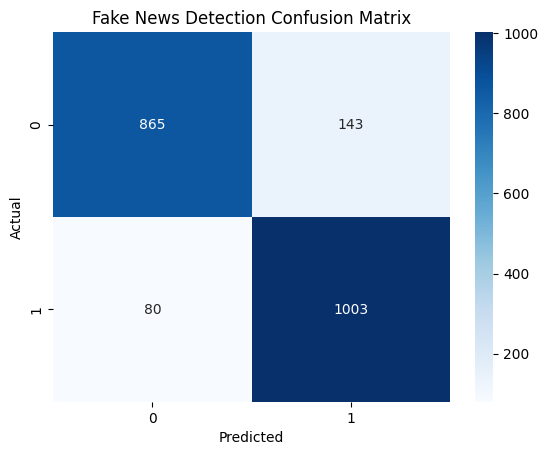

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fake News Detection Confusion Matrix")
plt.show()

Accuracy

Formula:

(TP + TN) / Total

Calculation:

(1003 + 865) / 2091

1868 / 2091

0.8934

======
Accuracy
89.34%

======

Step 4: Error Rate

Formula:

(FP + FN) / Total

Calculation:

143 + 80 = 223

223 / 2091

10.66%

========



| Actual \ Predicted | 0       | 1        |
| ------------------ | ------- | -------- |
| **0**              | **865** | **143**  |
| **1**              | **80**  | **1003** |

========

Assuming:

0 = FAKE

1 = REAL

========

| Metric                      | Value  |
| --------------------------- | ------ |
| Total News Articles         | 2091   |
| Correct Predictions         | 1868   |
| Wrong Predictions           | 223    |
| Accuracy                    | 89.34% |
| Error Rate                  | 10.66% |
| Correct Fake News Detection | 865    |
| Correct Real News Detection | 1003   |


"The first news article was converted into numerical form using CountVectorizer. The Multinomial Naive Bayes model analyzed the word frequencies and predicted the article as FAKE. The output array(['FAKE']) indicates that the model classified the article as fake news based on patterns learned during training."

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

        FAKE       0.92      0.86      0.89      1008
        REAL       0.88      0.93      0.90      1083

    accuracy                           0.89      2091
   macro avg       0.90      0.89      0.89      2091
weighted avg       0.89      0.89      0.89      2091



Test Custom News

In [ ]:
news = ["Scientists discover water on Mars"]

news_vector = count_vectorizer.transform(news)

prediction = clf.predict(news_vector)

print(prediction[0])

FAKE


In [ ]:
news = ["Aliens landed in Chennai yesterday"]
news_vector = count_vectorizer.transform(news)

prediction = clf.predict(news_vector)

print(prediction[0])

FAKE


In [ ]:
news = ["Government announces new education policy for students"]
news_vector = count_vectorizer.transform(news)

prediction = clf.predict(news_vector)

print(prediction[0])


REAL


In [ ]:
news = ["Government announces new education policy for students"]

news_vector = count_vectorizer.transform(news)

print(clf.predict(news_vector))

print(clf.predict_proba(news_vector))

['REAL']
[[0.29517258 0.70482742]]


| Class | Probability |
| ----- | ----------- |
| FAKE  | 29%         |
| REAL  | 71%         |


During training:

clf.fit(count_train, y_train)

The model learned which words frequently appear in:

REAL news
FAKE news

Example (simplified):

| Word       | REAL Count | FAKE Count |
| ---------- | ---------- | ---------- |
| government | 500        | 50         |
| policy     | 420        | 30         |
| education  | 350        | 20         |
| students   | 280        | 40         |
| aliens     | 5          | 120        |
| secret     | 15         | 180        |
